In [2]:
import pandas as pd

In [3]:
import numpy as np
import matplotlib.pyplot as plt


In [4]:
import seaborn as sns

In [5]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\user\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [7]:
import seaborn as sns

In [8]:
df = pd.read_csv(r"C:\Users\user\Downloads\archive (4)\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [9]:
df.shape

(7043, 21)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df.drop("customerID", axis=1, inplace=True)

In [12]:
df["TotalCharges"].head()

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: object

In [13]:
df["TotalCharges"].dtype

dtype('O')

In [14]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [16]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [17]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [18]:
df.duplicated().sum()

np.int64(22)

In [19]:
df[df.duplicated()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
964,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.70,Yes
1338,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes
1491,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
1739,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.90,69.90,Yes
1932,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.20,20.20,No
2713,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.45,20.45,No
2892,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.45,20.45,No
3301,Female,1,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.60,69.60,Yes
3754,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,No
4098,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.20,20.20,Yes


In [20]:
df[df.duplicated(keep=False)].sort_values(
    by=["MonthlyCharges", "TotalCharges"]
)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
542,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
1491,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
5170,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No
6774,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No
4817,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.90,19.90,No
6706,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.90,19.90,No
662,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,No
3754,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,No
5736,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,No
3679,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.10,20.10,Yes


In [21]:
df.drop_duplicates(inplace=True)

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
print(df.shape)
print(df["Churn"].value_counts())

(7021, 20)
Churn
No     5164
Yes    1857
Name: count, dtype: int64


In [24]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.550776
Yes    26.449224
Name: proportion, dtype: float64

In [25]:
# exploratory data analysis 


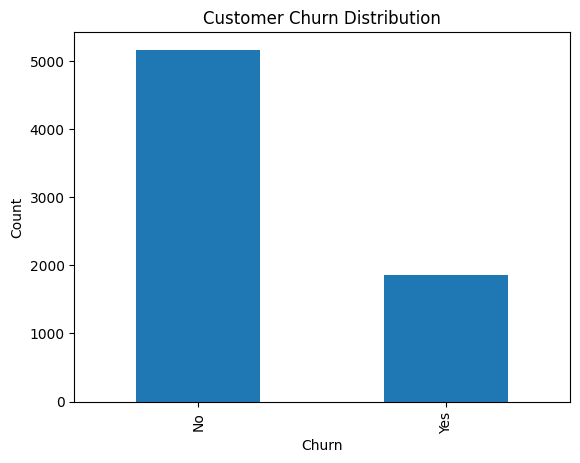

In [26]:
# why are customers leaving 
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

In [27]:
# Churn by Gender
pd.crosstab(df["gender"], df["Churn"])

Churn,No,Yes
gender,,
Female,2546,934
Male,2618,923


In [28]:
# Do males churn more than females?
pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
)*100

Churn,No,Yes
gender,,
Female,73.160920,26.839080
Male,73.933917,26.066083


In [29]:
#Churn by Contract Type
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2210,1643
One year,1307,166
Two year,1647,48


In [30]:
#Which contract has the highest churn?- Month-to-month
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
)*100

Churn,No,Yes
Contract,,
Month-to-month,57.357903,42.642097
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [31]:
# Do Fiber Optic customers churn more?
pd.crosstab(
    df["InternetService"],
    df["Churn"]
)


Churn,No,Yes
InternetService,,
DSL,1962,457
Fiber optic,1799,1291
No,1403,109


In [32]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
)*100

Churn,No,Yes
InternetService,,
DSL,81.107896,18.892104
Fiber optic,58.220065,41.779935
No,92.791005,7.208995


In [33]:
# Do customers with higher bills churn more? Monthly Charges Analysis
df.groupby("Churn")["MonthlyCharges"].mean()


Churn
No     61.344878
Yes    74.604308
Name: MonthlyCharges, dtype: float64

In [34]:
# Do new customers leave more often?Tenure Analysis
df.groupby("Churn")["tenure"].mean()

Churn
No     37.640782
Yes    18.088853
Name: tenure, dtype: float64

In [35]:
# Correlation Analysis (Numeric Columns) Interpretation

#Look for:
#Tenure vs Churn
#MonthlyCharges vs Churn
#TotalCharges vs Churn
df["Churn"] = df["Churn"].map(
    {"No":0,"Yes":1}
)

In [36]:
df[["SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn"]].corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
SeniorCitizen,1.000000,0.015349,0.219434,0.101886,0.151619
tenure,0.015349,1.000000,0.245251,0.824875,-0.351508
MonthlyCharges,0.219434,0.245251,1.000000,0.650341,0.194508
TotalCharges,0.101886,0.824875,0.650341,1.000000,-0.197911
Churn,0.151619,-0.351508,0.194508,-0.197911,1.000000


In [37]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index")*100 #Business Meaning These customers have no long-term commitment.They can leave anytime---Month-to-month.

Churn,0,1
Contract,,
Month-to-month,57.357903,42.642097
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [38]:
df.groupby("Churn")["tenure"].mean() #Do new customers leave more often?

Churn
0    37.640782
1    18.088853
Name: tenure, dtype: float64

In [39]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
)*100

Churn,0,1
Contract,,
Month-to-month,57.357903,42.642097
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [40]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index")*100
pd.crosstab(df["InternetService"], df["Churn"], normalize="index")*100

Churn,0,1
InternetService,,
DSL,81.107896,18.892104
Fiber optic,58.220065,41.779935
No,92.791005,7.208995


In [41]:
#Analysis 1: Contract Type vs Churn--- Business goal---Convert month-to-month customers into long-term customers.
pd.crosstab(
    df["Contract"],
    df["Churn"]
)

Churn,0,1
Contract,,
Month-to-month,2210,1643
One year,1307,166
Two year,1647,48


In [42]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,0,1
Contract,,
Month-to-month,57.357903,42.642097
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [43]:
#Analysis 2: Internet Service vs Churn
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,0,1
InternetService,,
DSL,81.107896,18.892104
Fiber optic,58.220065,41.779935
No,92.791005,7.208995


In [44]:
#Analysis 3: Payment Method vs Churn   Does payment method affect churn?-----Electronic check has the highest churn.
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.853752,45.146248
Mailed check,81.077694,18.922306


In [45]:
df.groupby("Churn")["MonthlyCharges"].mean() #Are customers with higher bills more likely to leave?Yes

Churn
0    61.344878
1    74.604308
Name: MonthlyCharges, dtype: float64

In [46]:
#In your Customer Churn dataset, tenure means:How long a customer has been with the company, measured in months.
#Higher tenure = More loyal customer
#Lower tenure = Higher churn risk
#Tenure represents the number of months a customer has remained with the company. It is an important indicator of customer loyalty and was one of the strongest predictors of churn in my analysis, showing a negative relationship with customer attrition."

In [47]:
# feature engineering 
#AvgRevenue
#HighValue
#LongTenure
#TenureGroup
#ServiceCount
df["AvgRevenue"] = df["TotalCharges"] / (df["tenure"] + 1)  #why +1 Reason Some customers may have: tenure = 0 If you divide by zero:1000 / 0Python throws an error:ZeroDivisionError Adding 1 prevents that.

In [48]:
df["HighValue"] = (
    df["MonthlyCharges"] > 80
).astype(int)

In [49]:
df["LongTenure"] = (
    df["tenure"] > 24
).astype(int)

In [50]:
df[["AvgRevenue","HighValue","LongTenure"]].head() # here Value	Meaning ,0	Normal customer, 1	High-value customer All these customers have: MonthlyCharges ≤ 80
# Value	Meaning
# 0	Customer stayed ≤ 24 months
# 1	Customer stayed > 24 months

,AvgRevenue,HighValue,LongTenure
0,14.925000,0,0
1,53.985714,0,1
2,36.050000,0,0
3,40.016304,0,1
4,50.550000,0,0


In [51]:
df["Churn"].unique()

array([0, 1])

In [52]:
df["ServiceCount"] = (
    (df["PhoneService"] == "Yes").astype(int) +
    (df["OnlineSecurity"] == "Yes").astype(int) +
    (df["OnlineBackup"] == "Yes").astype(int) +
    (df["DeviceProtection"] == "Yes").astype(int) +
    (df["TechSupport"] == "Yes").astype(int) +
    (df["StreamingTV"] == "Yes").astype(int) +
    (df["StreamingMovies"] == "Yes").astype(int)
)

In [53]:
df[["ServiceCount"]].head()

,ServiceCount
0,1
1,3
2,3
3,3
4,1


In [54]:
# Why is this useful?
#Imagine:
#Customer A
#ServiceCount = 1
#Uses only one service. Easy to leave.
#Customer B ,ServiceCount = 6,Uses many services.,More integrated with the company.Less likely to churn.

In [55]:
df["ServiceCount"].describe() #Business Insight --The average customer subscribes to about 3 services.
#---Standard deviation measures variation.Meaning:Customers don't all use exactly 3 services.Some use:0,1,2 while others use:5,6,7 services.
#--min=0 These customers may be more likely to churn.
#--25% of the customers use 1.service. 50%  uses 3.000000 .75% uses 4.000000.max uses 7.000000
# max = 7 Some customers use every service offered. These are often highly engaged customers.

count    7021.000000
mean        2.947159
std         1.843577
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max         7.000000
Name: ServiceCount, dtype: float64

In [56]:
# Do customers who use more services churn less?
df.groupby("Churn")["ServiceCount"].mean()
# Customers who are more engaged with the company's products are less likely to churn.
#Customers who churned subscribed to an average of 2.69 services, while retained customers used 3.04 services on average. 
#This indicates that greater service adoption is associated with stronger customer retention.

Churn
0    3.040279
1    2.688207
Name: ServiceCount, dtype: float64

In [57]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

In [58]:
df[["tenure", "TenureGroup"]].head(10)

,tenure,TenureGroup
0,1,0-12 Months
1,34,25-48 Months
2,2,0-12 Months
3,45,25-48 Months
4,2,0-12 Months
5,8,0-12 Months
6,22,13-24 Months
7,10,0-12 Months
8,28,25-48 Months
9,62,49-72 Months


In [59]:
# Prepare Data for Machine Learning

#Random Forest cannot understand text columns like:
#Male
#Female
#Month-to-month
#Fiber optic
#We must convert them to numbers.
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [60]:
print(df_encoded.shape)

(7021, 38)


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7021 non-null   object  
 1   SeniorCitizen     7021 non-null   int64   
 2   Partner           7021 non-null   object  
 3   Dependents        7021 non-null   object  
 4   tenure            7021 non-null   int64   
 5   PhoneService      7021 non-null   object  
 6   MultipleLines     7021 non-null   object  
 7   InternetService   7021 non-null   object  
 8   OnlineSecurity    7021 non-null   object  
 9   OnlineBackup      7021 non-null   object  
 10  DeviceProtection  7021 non-null   object  
 11  TechSupport       7021 non-null   object  
 12  StreamingTV       7021 non-null   object  
 13  StreamingMovies   7021 non-null   object  
 14  Contract          7021 non-null   object  
 15  PaperlessBilling  7021 non-null   object  
 16  PaymentMethod     7021 non-nu

In [62]:
#Next Step: Split Data into X and y
#What is X?
#Features used for prediction.
#Example:
#tenure
#MonthlyCharges
#Contract
#ServiceCount
#AvgRevenue
#What is y?
#Target variable.
#Churn
#The thing we want to predict.
X = df_encoded.drop("Churn", axis=1)

y = df_encoded["Churn"]

In [63]:
print(X.shape)
print(y.shape)

(7021, 37)
(7021,)


In [64]:
#Splits the dataset into training data (80%) and testing data (20%).
#Training data is used to teach the model, while testing data is used to evaluate its performance on unseen data.
#random_state=42 ensures the same random split is generated every time, making results consistent and reproducible.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [65]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
#X.shape = (7021, 37)
#y.shape = (7021,),,7021 customers (rows) ,37 features (columns)
#test_size = 0.2-----20% of data → Test Set----7021 × 0.2----1404.2 ≈ 1405---1405 customers → Test Data--7021 - 1405=5616--5616 customers → Training Data


(5616, 37)
(1405, 37)
(5616,)
(1405,)


In [66]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)  #n_estimators=200 Means:Create 200 decision trees Instead of relying on one tree, Random Forest combines predictions from 200 trees, making it more accurate and stable.
#random_state=42 ,Ensures the same model is created every time you run the code.

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [67]:
preds = rf.predict(X_test) #For each of the 1405 test customers, the model predicts:

#0 = Stay
#1 = Churn

In [68]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, preds)

print("Accuracy:", accuracy) #Accuracy tells us: Out of all predictions, how many were correct?Example:

#100 customers tested
#87 predicted correctly
#Accuracy = 87%

Accuracy: 0.7857651245551601


In [69]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)

print(cm) 
#| Actual \ Predicted | Stay (0)     | Churn (1)     |
#| ------------------ | ------------ | ------------- |
#| Stay (0)           | Correct Stay | Wrong Churn   |
#| Churn (1)          | Missed Churn | Correct Churn |
#This tells us:

#How many churners we successfully detected.  # True Negatives (TN)--937 ,116 → False Positives (FP),185 → False Negatives (FN),167 → True Positives (TP)
#How many churners we missed.

[[937 116]
 [185 167]]


In [ ]:
#Total Customers Evaluated
#Calculation:
#937 + 116 + 185 + 167 = 1405
#Therefore:
#Total test customers = 1405
#This matches the size of the test dataset.
#Churn Detection Rate (Recall)
#Actual churned customers:
#185 + 167 = 352
#Customers correctly identified as churners:
#167
#Recall Calculation:
#167 / 352 = 0.474
#Recall = 47.4%
#Interpretation
#The model successfully identified 47.4% of all customers who actually churned.

#Business Interpretation
#Strengths
#The model is strong at identifying customers who are likely to stay.
#It correctly classified 937 loyal customers.
#Improvement Area
#The model missed 185 customers who eventually churned.
#These customers represent potential revenue loss because the business would not have targeted them with retention efforts.
#Key Insight
#The dataset contains significantly more customers who stay than customers who churn. Because of this imbalance, the model naturally becomes better at predicting "stay" customers than "churn" customers.

#Model Performance Summary
#Metric	Value
#Accuracy	78.58%
#Correct Stay Predictions	937
#Correct Churn Predictions	167
#Missed Churn Customers	185
#Total Test Customers	1405
#Resume-Friendly Project Insight

#Developed a Random Forest-based Customer Churn Prediction model achieving 78.6% accuracy on customer retention data. The model correctly identified 167 at-risk customers and uncovered churn patterns related to contract type, tenure, monthly charges, and service adoption, enabling targeted retention strategies and churn-risk segmentation.

#Interview Explanation

#If an interviewer asks:

#"What did you learn from the confusion matrix?"

#You can answer:

#"The confusion matrix showed that the model correctly identified 937 retained customers and 167 churned customers. However, it missed 185 actual churners, indicating an opportunity to improve recall. This analysis helped me understand where the model performs well and where retention-focused improvements could be made."

In [70]:
#ROC-AUC
from sklearn.metrics import roc_auc_score

probs = rf.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, probs)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.823755719589053


In [ ]:
#| ROC-AUC   | Interpretation  |
#| --------- | --------------- |
#| 0.50      | Random guessing |
#| 0.60–0.70 | Weak            |
#| 0.70–0.80 | Good            |
#| 0.80–0.90 | Very Good       |
#| 0.90+     | Excellent       |


In [71]:
# Feature Importance
#This tells us:
#Which features were most influential in predicting churn?
#This is one of the most valuable business insights in your project.
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                           Feature  Importance
3                     TotalCharges    0.139791
2                   MonthlyCharges    0.126876
4                       AvgRevenue    0.124327
1                           tenure    0.121782
14     InternetService_Fiber optic    0.037035
32  PaymentMethod_Electronic check    0.032927
7                     ServiceCount    0.031808
6                       LongTenure    0.030235
8                      gender_Male    0.023845
30            PaperlessBilling_Yes    0.022644


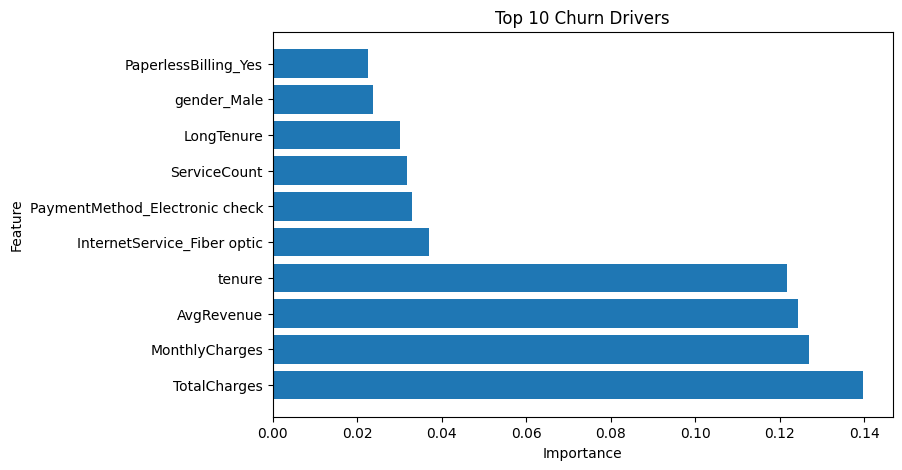

In [72]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10["Feature"], top10["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Churn Drivers")
plt.show()

In [ ]:
# 1 Business Insight Customers with different spending patterns behave differently.
#Higher lifetime value customers often have different retention characteristics than low-spending customers.
# 2 Monthly bill amount strongly affects churn.Business Insight
#Customers paying higher monthly charges may be more likely to compare competitors and switch providers.
# 3 Business Insight Average customer value per month helps distinguish loyal customers from potentially risky ones.
#This shows your feature engineering added useful information.
# 4 Business Insight
#Customers who stay longer tend to be less likely to churn.
#This matches your earlier analysis:
#Stayed Customers: 37.6 months
#Churned Customers: 18.1 months
# 5 Internet type influences churn behavior.
#Business Insight
#Fiber optic users may have different expectations, pricing sensitivity, or service experiences.
# 6 Payment method contributes to churn prediction.Business Insight
#Certain payment methods may be associated with higher churn risk.
# 7. ServiceCount
#Importance = 0.0318
#Another engineered feature.
#Business Insight
#Customers using more services tend to be more engaged and less likely to leave.
# 8. LongTenure
#Importance = 0.0302
#Your engineered loyalty flag is helping the model.
#Business Insight
#Long-term customers behave differently from newer customers.


In [73]:
probs = rf.predict_proba(X)[:, 1]

df["Churn_Probability"] = probs

high_risk = df[df["Churn_Probability"] > 0.7]

print("High Risk Customers:", len(high_risk))

High Risk Customers: 1382


In [ ]:
# means:Out of 7021 customers, your model believes 1382 customers have more than a 70% probability of churning.
#1382 / 7021 * 100 = 19.7%
#Nearly 1 in every 5 customers is classified as high risk and may require proactive retention efforts.
#| Risk Segment             | Recommended Action    |
#| ------------------------ | --------------------- |
#| New Customers            | Onboarding Campaign   |
#| Month-to-Month Customers | Annual Contract Offer |
#| High Monthly Charges     | Personalized Discount |
#| High-Value Customers     | Loyalty Rewards       |
#| High-Risk Customers      | Retention Outreach    |


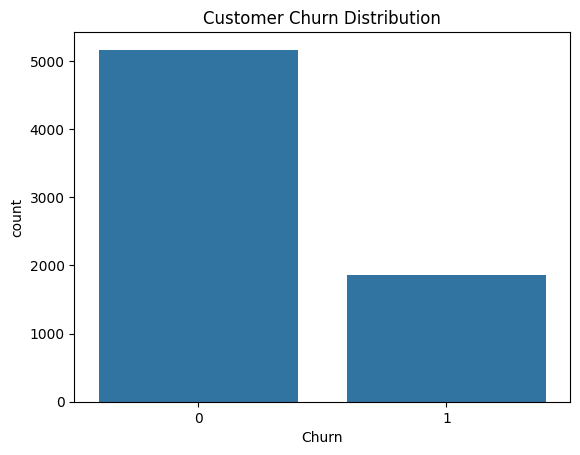

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

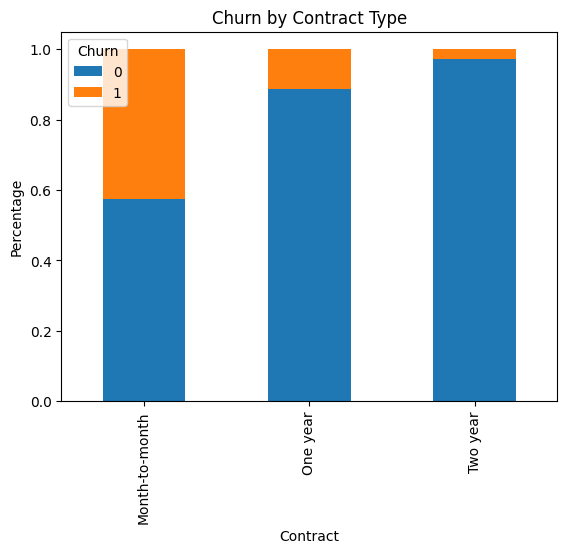

In [75]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
).plot(kind="bar", stacked=True)

plt.title("Churn by Contract Type")
plt.ylabel("Percentage")
plt.show()

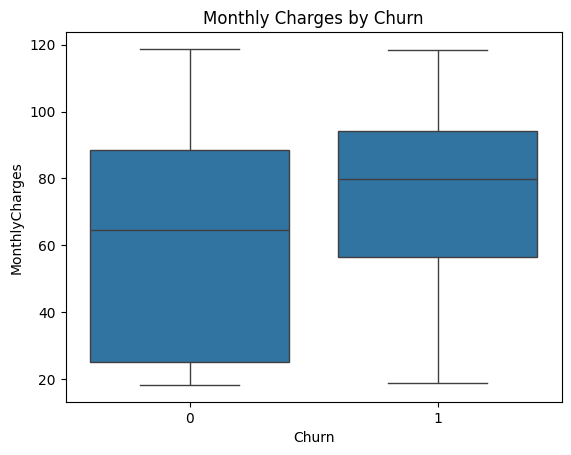

In [76]:
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges by Churn")
plt.show()

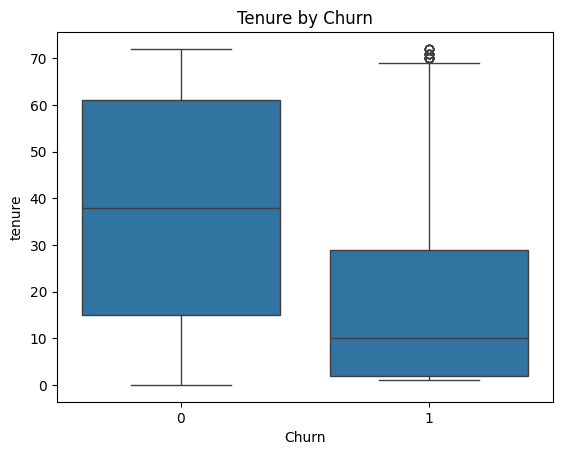

In [77]:
sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Tenure by Churn")
plt.show()

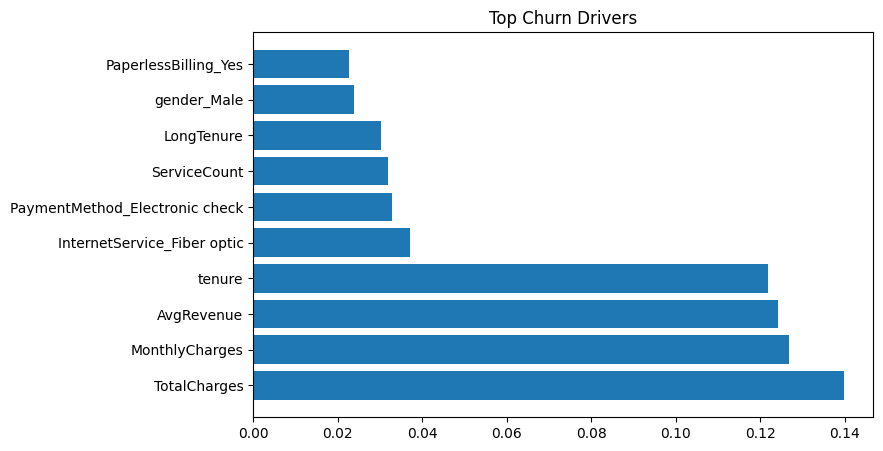

In [78]:
top10 = importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10["Feature"], top10["Importance"])
plt.title("Top Churn Drivers")
plt.show()

In [79]:
df["RiskLevel"] = pd.cut(
    df["Churn_Probability"],
    bins=[0,0.3,0.7,1],
    labels=["Low Risk","Medium Risk","High Risk"]
)

df["RiskLevel"].value_counts()

RiskLevel
Low Risk       4256
High Risk      1382
Medium Risk     711
Name: count, dtype: int64

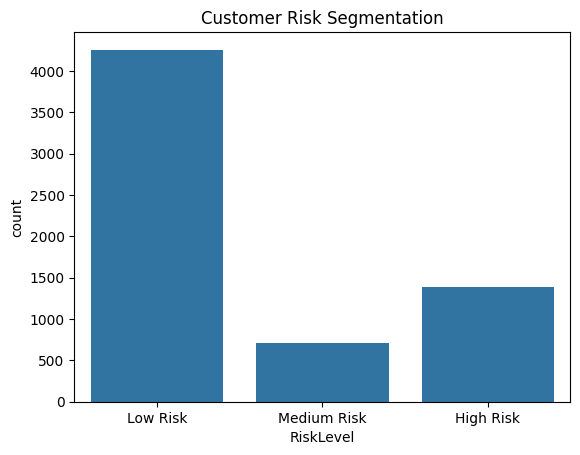

In [80]:
sns.countplot(x="RiskLevel", data=df)
plt.title("Customer Risk Segmentation")
plt.show()

In [81]:
high_risk["MonthlyCharges"].sum()

np.float64(106910.65)

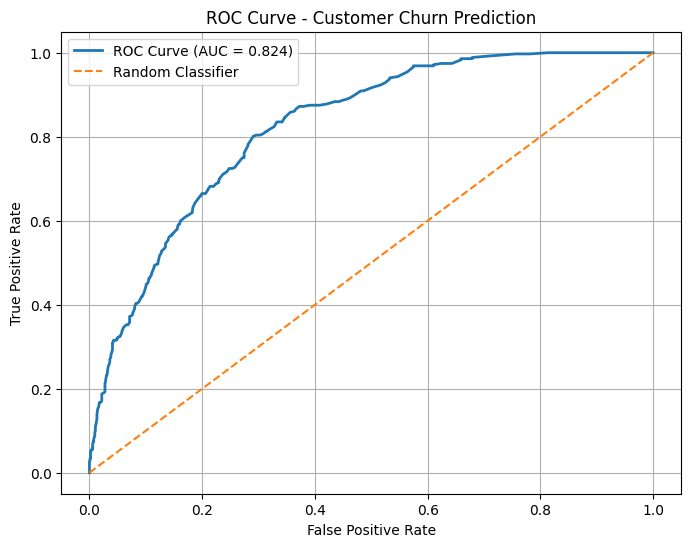

In [82]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get churn probabilities
y_probs = rf.predict_proba(X_test)[:, 1]

# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_probs)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {auc_score:.3f})",
    linewidth=2
)

# Random Guess Line
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn Prediction")
plt.legend()
plt.grid(True)

plt.show()